# Creating a New `MUAEphysSession` in the Utah Organoids Pipeline

### **Overview**

This notebook guides you through the process of creating and inserting a new **MUAEphysSession** in the Utah Organoids pipeline.
- A `MUAEphysSession` represents a specific time-window (1 minute per file) for multi-unit activity (MUA) analysis.
- Each session is linked to an experiment and specifies which raw ephys data files to process.

By the end of this notebook, you will have:
- Selected an experiment from the `Experiment` table
- Identified available raw ephys files within the experiment time window
- Visualized already-processed and pending MUA sessions
- Inserted new `MUAEphysSession` entries for specified time windows

**_Note:_**
- This notebook uses example data; replace values with actual database entries.
- Each `MUAEphysSession` corresponds to one raw data file (~1 minute duration).
- Duplicate entries are automatically ignored during insertion.

### **Key Steps**

- **Setup**

- **Step 1: Select an Experiment**

- **Step 2: Ensure EphysSession and EphysSessionProbe Exist**

- **Step 3: Check Data Availability**

- **Step 4: Select Boundaries to Insert New MUA Sessions**

- **Step 5: Insert MUAEphysSessions**

#### **Setup**


First, import the necessary packages for the data pipeline and essential schemas.


In [2]:
## Ensure the correct working directory

import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
import datajoint as dj
from datetime import datetime, timedelta
import numpy as np
from matplotlib import pyplot as plt

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
from workflow.pipeline import culture, ephys, probe, mua

[2026-02-11 18:10:50,397][INFO]: DataJoint 0.14.4 connected to judewerth@db.datajoint.com:3306


Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


#### **Step 1: Select an Experiment**

Each `Session` must be linked to an existing **experiment** stored in the `Experiment` table. Experiments track organoid testing under various conditions. The metadata of this table was previously inserted through the Organoid Generation Pipeline using Organoids SciViz.


Check available experiments and select one to link to the new session:

In [5]:
experiment_entries = culture.Experiment().proj(
    "experiment_end_time", "drug_name", "drug_concentration", "experiment_plan"
)
experiment_entries

organoid_id e.g. O17,experiment_start_time,experiment_end_time,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
E01,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E02,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E03,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E04,2024-08-30 19:43:00,2024-08-30 19:51:00,Control,nan,ephys
E09,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
E10,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
E11,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
E12,2024-10-30 13:09:00,2024-10-30 13:15:00,Control,nan,ephys
MB01,2024-08-30 19:00:00,2024-08-30 19:26:00,Control,nan,ephys
MB02,2024-08-30 19:00:00,2024-08-30 19:26:00,Control,nan,ephys


Experiments are identified by their unique `organoid_id` and `experiment_start_time`. You can choose an experiment based on these identifiers.


In [6]:
organoid_id = "O24"

exp_key = {
    "organoid_id": organoid_id,
}

experiment_entries & exp_key

organoid_id e.g. O17,experiment_start_time,experiment_end_time,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
O24,2024-07-01 13:53:00,2024-07-09 13:25:00,Control,nan,ephys
O24,2024-07-09 13:45:00,2024-07-09 17:45:00,4-AP,100.0,ephys
O24,2024-07-09 18:00:00,2024-07-10 10:45:00,No Drug,nan,ephys
O24,2024-07-10 10:50:00,2024-07-10 15:50:00,Bicuculline,50.0,ephys
O24,2024-07-10 16:05:00,2024-07-11 16:20:00,Tetrodotoxin,1.0,ephys


In [7]:
drug_name = "Control"
experiment_start_time = (experiment_entries & exp_key & f"drug_name = '{drug_name}'").fetch1("experiment_start_time")

exp_key["experiment_start_time"] = experiment_start_time

#### **Step 2: Ensure at least one `EphysSession` and `EphysSessionProbe` have been inserted for the given experiment**

In [8]:
ephys_sessions = ephys.EphysSessionProbe & exp_key

if len(ephys_sessions) == 0:
    raise ValueError(
        f"No EphysSessionProbe found for organoid {organoid_id} and experiment starting at {experiment_start_time}. Please insert EphysSession and EphysSessionProbe entries first."
    )
else:
    print(f"Found {len(ephys_sessions)} EphysSessionProbe entries for organoid {organoid_id} and experiment starting at {experiment_start_time}.\nContinue to create MUA session entry.")

Found 4 EphysSessionProbe entries for organoid O24 and experiment starting at 2024-07-01 13:53:00.
Continue to create MUA session entry.


#### **Step 3: Check Data Availability**

**MUAEphysSession** controls which time segments are processed for MUA analysis. Along with `organoid_id` and `experiment_start_time`, you need to specify a `start_time`. 

**MUAEphysSession** entries are each one minute (corresponding to the duration of the saved rhd files). Before creating a new session, check that the desired time segment is available in the raw data and has not yet been processed.

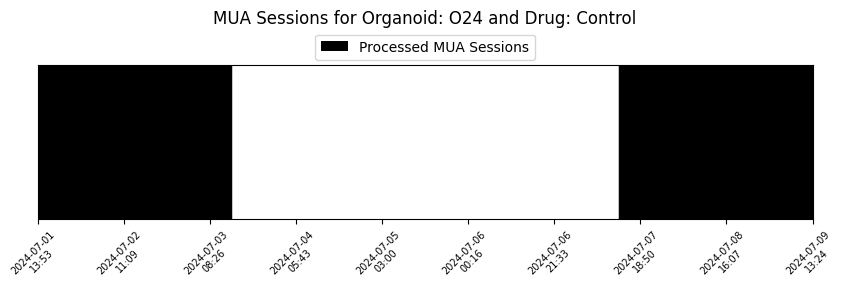

In [9]:
def downsample_to_length(x, n_new):

    """Downsample 1D array x to length n_new using linear interpolation."""
    new_idx = np.linspace(0, x.size - 1, n_new).astype(int)
    return x[new_idx]

# determine the experiment boundaries (based on exp_key)
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")

# find the available files within the experiment boundaries
file_times = (ephys.EphysRawFile & exp_key & f"file_time >= '{experiment_start_time}' AND file_time < '{experiment_end_time}'").fetch("file_time")

# find the processed MUA sessions within the experiment boundaries
processed_file_times = (mua.MUAEphysSession & exp_key & f"start_time >= '{experiment_start_time}' AND start_time < '{experiment_end_time}'").fetch("start_time")

# create a visualization of the data already processed for the given exp_key
fig = plt.figure(figsize=(10, 2))
ax = fig.gca()

processed_bool = np.isin(file_times, processed_file_times)
ax.imshow(processed_bool[np.newaxis, :], aspect="auto", cmap="binary")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='black', label='Processed MUA Sessions')]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
)

plt.show()

#### **Step 4: Select Boundaries to Insert New MUA Sessions**

Based on the visualization above, select the start and end times for the new MUA sessions to be created. Ensure that these times fall within the experiment boundaries. Duplicated entries will be automatically ignored during insertion.

In [10]:
# TODO: adjust session time range as needed
session_start_time = experiment_start_time
session_end_time = experiment_start_time + timedelta(days=2)


insert_file_times = file_times[(session_start_time <= file_times) & (file_times < session_end_time)]
print(f"Preparing to insert MUA sessions from {session_start_time} to {session_end_time} ({len(insert_file_times)} files)")

Preparing to insert MUA sessions from 2024-07-01 13:53:00 to 2024-07-03 13:53:00 (2880 files)


New Visualization Showing MUA Sessions to be Inserted

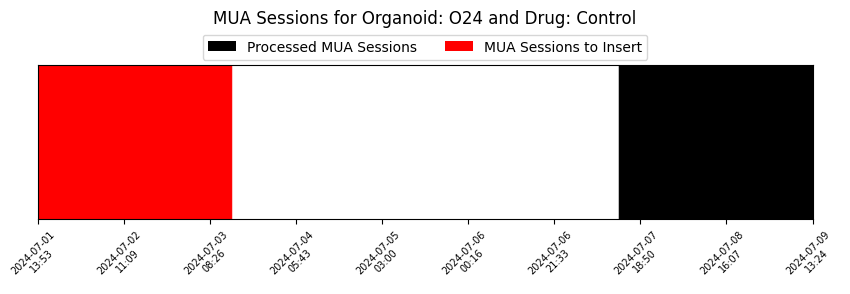

In [11]:
insert_bool = np.isin(file_times, insert_file_times)

# Create RGB visualization showing both processed and insert sessions
rgb_image = np.ones((1, len(file_times), 3))

# Red for sessions to be inserted
rgb_image[insert_bool[np.newaxis, :]] = [1, 0, 0]

# Black for already processed sessions (not being inserted)
rgb_image[processed_bool[np.newaxis, :] & ~insert_bool[np.newaxis, :]] = [0, 0, 0]

fig = plt.figure(figsize=(10, 2))
ax = fig.gca()
ax.imshow(rgb_image, aspect="auto")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='Processed MUA Sessions'),
    Patch(facecolor='red', label='MUA Sessions to Insert')
]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
    ncol=2,
)

plt.show()

#### **Step 5: Insert MUAEphysSessions based on previously defined Parameters**

In [12]:
# get port_id (needed for insert)
port_id = set((ephys.EphysSessionProbe & exp_key).fetch("port_id"))

# Check if there are multiple port IDs for the same experiment, if so, it needs to be fixed in the EphysSessionProbe table
if len(port_id) > 1:
    raise ValueError(
        f"Multiple Port IDs found for the {exp_key} - cannot determine the port ID"
    )
port_id = port_id.pop()

In [13]:
# get port_id (needed for insert)

mua_key_list = [
    {
        **exp_key,
        "start_time": start_time,
        "end_time": start_time + timedelta(minutes=1),
        "port_id": port_id,
    }
    for start_time in insert_file_times
]

mua.MUAEphysSession & mua_key_list

organoid_id e.g. O17,experiment_start_time,start_time,end_time,"port_id e.g. A, B, C, ..."
O24,2024-07-01 13:53:00,2024-07-01 13:53:04,2024-07-01 13:54:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:54:04,2024-07-01 13:55:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:55:04,2024-07-01 13:56:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:56:04,2024-07-01 13:57:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:57:04,2024-07-01 13:58:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:58:04,2024-07-01 13:59:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:59:04,2024-07-01 14:00:04,D
O24,2024-07-01 13:53:00,2024-07-01 14:00:04,2024-07-01 14:01:04,D
O24,2024-07-01 13:53:00,2024-07-01 14:01:04,2024-07-01 14:02:04,D
O24,2024-07-01 13:53:00,2024-07-01 14:02:04,2024-07-01 14:03:04,D


In [14]:
# mua.MUAEphysSession.insert(mua_key_list, skip_duplicates=True, allow_direct_insert=True)

In [15]:
mua.MUAEphysSession & mua_key_list

organoid_id e.g. O17,experiment_start_time,start_time,end_time,"port_id e.g. A, B, C, ..."
O24,2024-07-01 13:53:00,2024-07-01 13:53:04,2024-07-01 13:54:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:54:04,2024-07-01 13:55:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:55:04,2024-07-01 13:56:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:56:04,2024-07-01 13:57:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:57:04,2024-07-01 13:58:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:58:04,2024-07-01 13:59:04,D
O24,2024-07-01 13:53:00,2024-07-01 13:59:04,2024-07-01 14:00:04,D
O24,2024-07-01 13:53:00,2024-07-01 14:00:04,2024-07-01 14:01:04,D
O24,2024-07-01 13:53:00,2024-07-01 14:01:04,2024-07-01 14:02:04,D
O24,2024-07-01 13:53:00,2024-07-01 14:02:04,2024-07-01 14:03:04,D


### Optional Step: Verify if Data has been Processed. (Check mua.MUASpikes)

In [16]:
mua.MUASpikes & mua_key_list

organoid_id e.g. O17,experiment_start_time,start_time,threshold_uv uV threshold for spike detection,peak_sign peak sign for spike detection,fs sampling frequency in Hz,execution_duration execution duration in hours
O24,2024-07-01 13:53:00,2024-07-01 13:53:04,50.0,both,20000.0,0.029887
O24,2024-07-01 13:53:00,2024-07-01 13:54:04,50.0,both,20000.0,0.0282278
O24,2024-07-01 13:53:00,2024-07-01 13:55:04,50.0,both,20000.0,0.029682
O24,2024-07-01 13:53:00,2024-07-01 13:56:04,50.0,both,20000.0,0.0298333
O24,2024-07-01 13:53:00,2024-07-01 13:57:04,50.0,both,20000.0,0.0290062
O24,2024-07-01 13:53:00,2024-07-01 13:58:04,50.0,both,20000.0,0.0345632
O24,2024-07-01 13:53:00,2024-07-01 13:59:04,50.0,both,20000.0,0.0338776
O24,2024-07-01 13:53:00,2024-07-01 14:00:04,50.0,both,20000.0,0.0346498
O24,2024-07-01 13:53:00,2024-07-01 14:01:04,50.0,both,20000.0,0.0297082
O24,2024-07-01 13:53:00,2024-07-01 14:02:04,50.0,both,20000.0,0.0372221
